<a href="https://colab.research.google.com/github/SameekshaPadigelawar/DEEP-LEARNING-PRACTICE/blob/main/DL_OBSERVATIONS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

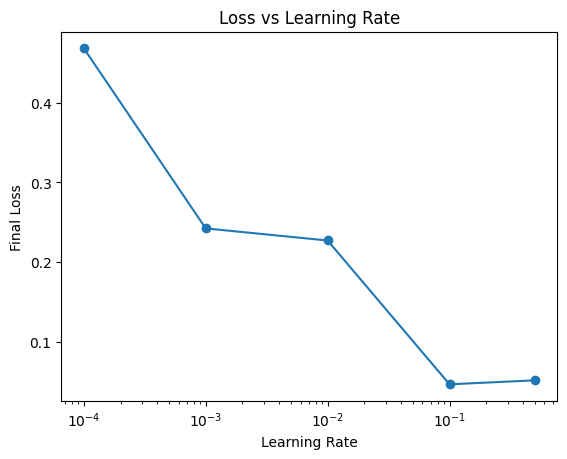

In [ ]:
#WEEK-3
import numpy as np
import matplotlib.pyplot as plt

# Create dataset (simple binary classification)
np.random.seed(0)
X = np.random.randn(200, 2)
y = (X[:, 0] * X[:, 1] > 0).astype(int).reshape(-1, 1)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# MLP Class
class MLP:
    def __init__(self):
        self.W1 = np.random.randn(2, 5)
        self.b1 = np.random.randn(1, 5)
        self.W2 = np.random.randn(5, 1)
        self.b2 = np.random.randn(1, 1)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, lr):
        error = y - output
        d_output = error * sigmoid_derivative(output)

        error_hidden = np.dot(d_output, self.W2.T)
        d_hidden = error_hidden * sigmoid_derivative(self.a1)

        self.W2 += np.dot(self.a1.T, d_output) * lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        self.W1 += np.dot(X.T, d_hidden) * lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

        loss = np.mean(np.square(error))
        return loss

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
losses = []

# Training loop
for lr in learning_rates:
    model = MLP()
    epochs = 200

    for _ in range(epochs):
        output = model.forward(X)
        loss = model.backward(X, y, output, lr)

    losses.append(loss)

# Plot Loss vs Learning Rate
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.show()

np.random.seed(0)
This sets the seed for numpy's random number generator. This ensures that the "random" numbers generated later will be the same every time the code is run, making the results reproducible.

X = np.random.randn(200, 2)
This creates a 2D array named X using numpy.random.randn. It generates 200 samples, each with 2 features, drawn from a standard normal distribution (mean 0, variance 1).

y = (X[:, 0] * X[:, 1] > 0).astype(int).reshape(-1, 1)
This line creates the target labels y for binary classification:

X[:, 0] * X[:, 1]: Multiplies the first feature by the second feature for each sample.
> 0: Creates a boolean array where True if the product is positive, False otherwise.
.astype(int): Converts the boolean array to integers (True becomes 1, False becomes 0).
.reshape(-1, 1): Reshapes the array into a column vector (200 rows, 1 column), which is a common format for target labels in machine learning.
# Activation functions
Comment indicating the definition of activation functions.

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
This defines the sigmoid activation function, which squashes any real-valued number into a range between 0 and 1. It's often used in the output layer of binary classification problems or in hidden layers.

def sigmoid_derivative(x):
    return x * (1 - x)
This defines the derivative of the sigmoid function. This specific form (x * (1 - x)) is used when x is already the output of the sigmoid function (i.e., sigmoid(z)). It's crucial for the backpropagation algorithm.

# MLP Class
Comment indicating the definition of the Multi-Layer Perceptron (MLP) class.

class MLP:
This declares a Python class named MLP, which will encapsulate the structure and behavior of our neural network.

    def __init__(self):
This is the constructor method for the MLP class. It's called when a new MLP object is created.

        self.W1 = np.random.randn(2, 5)
Initializes the weight matrix W1 for the first layer (input to hidden layer). It has dimensions (2, 5) because there are 2 input features and 5 hidden neurons.

        self.b1 = np.random.randn(1, 5)
Initializes the bias vector b1 for the hidden layer. It has dimensions (1, 5) because there's one bias term for each of the 5 hidden neurons.

        self.W2 = np.random.randn(5, 1)
Initializes the weight matrix W2 for the second layer (hidden to output layer). It has dimensions (5, 1) because there are 5 hidden neurons and 1 output neuron.

        self.b2 = np.random.randn(1, 1)
Initializes the bias vector b2 for the output layer. It has dimensions (1, 1) because there's one bias term for the single output neuron.

    def forward(self, X):
This defines the forward method of the MLP class, which calculates the network's output given an input X.

        self.z1 = np.dot(X, self.W1) + self.b1
Calculates the weighted sum of inputs plus bias for the hidden layer. np.dot performs matrix multiplication of X and W1, then b1 is added (broadcasting applies).

        self.a1 = sigmoid(self.z1)
Applies the sigmoid activation function to the result of z1 to get the activation of the hidden layer, a1.

        self.z2 = np.dot(self.a1, self.W2) + self.b2
Calculates the weighted sum of inputs plus bias for the output layer, using the activated hidden layer a1.

        self.a2 = sigmoid(self.z2)
Applies the sigmoid activation function to the result of z2 to get the final output of the network, a2.

        return self.a2
Returns the network's prediction (output).

    def backward(self, X, y, output, lr):
This defines the backward method, which performs backpropagation to update the network's weights and biases. It takes input X, true labels y, the network's output (prediction), and the learning_rate (lr).

        error = y - output
Calculates the difference between the true labels (y) and the network's prediction (output), which represents the error at the output layer.

        d_output = error * sigmoid_derivative(output)
Calculates the delta (gradient) for the output layer. This is the error multiplied by the derivative of the sigmoid function applied to the output.

        error_hidden = np.dot(d_output, self.W2.T)
Propagates the error backward from the output layer to the hidden layer. It's the dot product of the output layer delta and the transpose of W2.

        d_hidden = error_hidden * sigmoid_derivative(self.a1)
Calculates the delta (gradient) for the hidden layer. This is the propagated error multiplied by the derivative of the sigmoid function applied to the hidden layer's activation (a1).

        self.W2 += np.dot(self.a1.T, d_output) * lr
Updates the weights W2. It's the dot product of the transpose of the hidden layer activations (a1.T) and the output delta, scaled by the learning rate.

        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
Updates the biases b2. It's the sum of the output deltas across all samples, scaled by the learning rate. keepdims=True maintains the shape for correct broadcasting.

        self.W1 += np.dot(X.T, d_hidden) * lr
Updates the weights W1. It's the dot product of the transpose of the input X and the hidden layer delta, scaled by the learning rate.

        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr
Updates the biases b1. It's the sum of the hidden layer deltas across all samples, scaled by the learning rate.

        loss = np.mean(np.square(error))
Calculates the mean squared error (MSE) as a measure of the network's performance. np.square squares each element of the error, and np.mean takes the average.

        return loss
Returns the calculated loss for the current iteration.

# Learning rates to test
Comment indicating the definition of learning rates for testing.

learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
Creates a list of different learning rate values that will be used to train the MLP model. A learning rate determines the step size at each iteration while moving toward a minimum of a loss function.

losses = []
Initializes an empty list to store the final loss value corresponding to each learning rate.

# Training loop
Comment indicating the start of the training process.

for lr in learning_rates:
This loop iterates through each learning rate defined in the learning_rates list.

    model = MLP()
Inside the loop, for each learning rate, a new instance of the MLP model is created. This ensures that each learning rate experiment starts with randomly initialized weights and biases, making the comparison fair.

    epochs = 200
Sets the number of training epochs (iterations) for each model to 200.

    for _ in range(epochs):
This inner loop runs for the specified number of epochs to train the current model.

        output = model.forward(X)
Performs a forward pass using the current input X to get the model's predictions.

        loss = model.backward(X, y, output, lr)
Performs a backward pass, updating the model's weights and biases based on the error and the current lr, and calculates the loss for the current epoch.

    losses.append(loss)
After 200 epochs, the final loss for the current learning rate is appended to the losses list.

# Plot Loss vs Learning Rate
Comment indicating the purpose of the following plotting code.

plt.plot(learning_rates, losses, marker='o')
Creates a line plot with learning_rates on the x-axis and the corresponding losses on the y-axis. marker='o' adds circular markers at each data point.

plt.xscale('log')
Sets the x-axis scale to logarithmic. This is useful when the x-axis values (learning rates, in this case) span several orders of magnitude.

plt.xlabel("Learning Rate")
Sets the label for the x-axis to "Learning Rate".

plt.ylabel("Final Loss")
Sets the label for the y-axis to "Final Loss".

plt.title("Loss vs Learning Rate")
Sets the title of the plot to "Loss vs Learning Rate".

plt.show()
Displays the generated plot.

/tmp/ipykernel_9847/3685103248.py:13: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


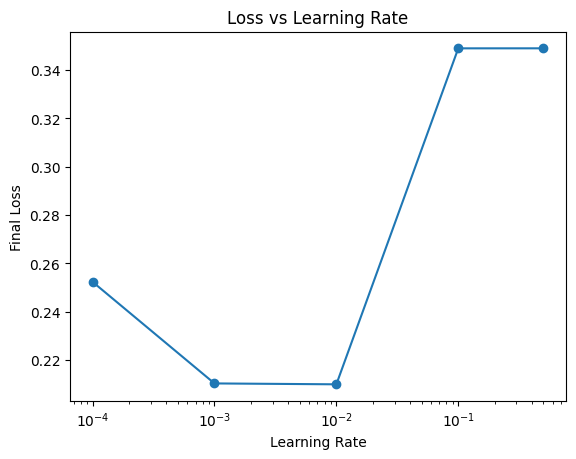

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace 'your_dataset.csv' with the path to your CSV file
df = pd.read_csv('diabetes_DT.csv')
# Example for X (features - ensure it's a NumPy array)
X = df.drop("Outcome",axis=1).values # Convert to numpy array
y = df['Outcome'].values.reshape(-1, 1)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# MLP Class
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.random.randn(1, hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.random.randn(1, output_size)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, lr):
        error = y - output
        d_output = error * sigmoid_derivative(output)

        error_hidden = np.dot(d_output, self.W2.T)
        d_hidden = error_hidden * sigmoid_derivative(self.a1)

        self.W2 += np.dot(self.a1.T, d_output) * lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        self.W1 += np.dot(X.T, d_hidden) * lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

        loss = np.mean(np.square(error))
        return loss

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
losses = []

# Determine input and output sizes from the data
input_size = X.shape[1]  # Number of features in X
hidden_size = 5          # Number of neurons in the hidden layer
output_size = y.shape[1] # Number of output neurons (1 for binary classification)

# Training loop
for lr in learning_rates:
    # Initialize MLP with correct input and output sizes
    model = MLP(input_size, hidden_size, output_size)
    epochs = 200

    for _ in range(epochs):
        output = model.forward(X)
        loss = model.backward(X, y, output, lr)

    losses.append(loss)

# Plot Loss vs Learning Rate
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.show()



---

### 📊 What your graph is saying

* **Very small learning rate (0.0001)**
  → Loss is **higher (~0.25)**
  → Model learns **too slowly** and doesn’t converge well

* **Moderate learning rates (0.001 and 0.01)**
  → Loss is **lowest (~0.21)**
  → ✅ **Best performance**
  → Model learns efficiently and converges properly

* **Large learning rates (0.1 and 0.5)**
  → Loss **increases (~0.35)**
  → Model becomes **unstable**
  → It may be **overshooting** the optimal solution

---

### 🧠 Key Insight

👉 There is an **optimal learning rate range** (here around **0.001–0.01**)

* Too small → slow learning
* Too large → unstable / poor learning

---

### 📌 Conclusion

> The graph shows that the learning rate significantly impacts model performance. Moderate learning rates (0.001–0.01) produce the lowest loss, indicating better convergence. Very small learning rates result in slow learning, while large learning rates cause instability and higher error.




Testing Perceptron with different eta0 (learning rate) values:

  eta0: 0.0001, Accuracy: 0.6558
  eta0: 0.001, Accuracy: 0.6558
  eta0: 0.01, Accuracy: 0.6558
  eta0: 0.1, Accuracy: 0.7078
  eta0: 1.0, Accuracy: 0.7078


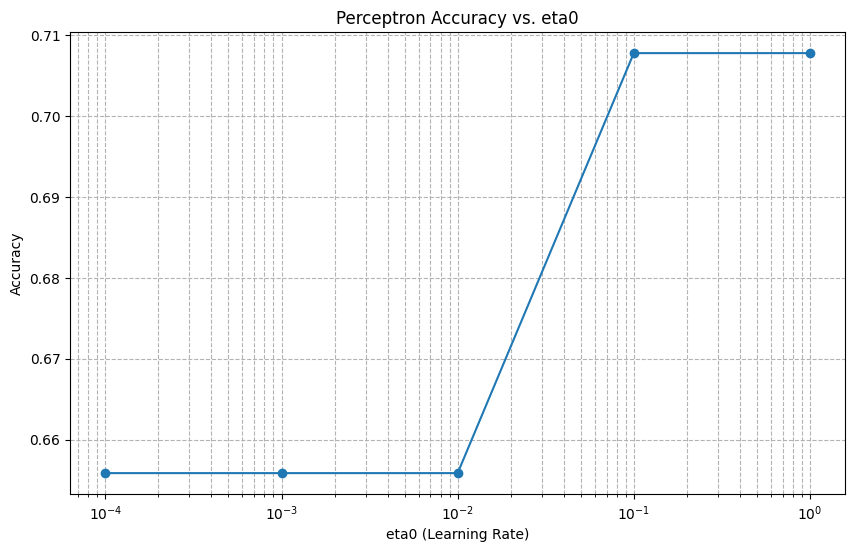

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas to read the CSV
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('diabetes_DT.csv')

# Separate features (X) and target (y)
# 'Outcome' is assumed to be your target column
X = df.drop('Outcome', axis=1) # All columns except 'Outcome' are features
y = df['Outcome']              # 'Outcome' is the target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 🔥 IMPORTANT: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Learning rates (eta0) to test
eta0_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
accuracies = []

print("Testing Perceptron with different eta0 (learning rate) values:\n")
for eta0_val in eta0_values:
    # Create a Perceptron object with the current eta0
    # max_iter is set explicitly to avoid convergence warnings with default tol
    perceptron = Perceptron(eta0=eta0_val, random_state=0, max_iter=1000, tol=1e-3)

    # Train the Perceptron on the training data
    perceptron.fit(X_train, y_train)

    # Use the trained Perceptron to make predictions on the testing data
    y_pred = perceptron.predict(X_test)

    # Evaluate the accuracy of the Perceptron
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"  eta0: {eta0_val}, Accuracy: {accuracy:.4f}")

# Plot Accuracy vs eta0
plt.figure(figsize=(10, 6))
plt.plot(eta0_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("eta0 (Learning Rate)")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy vs. eta0")
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()


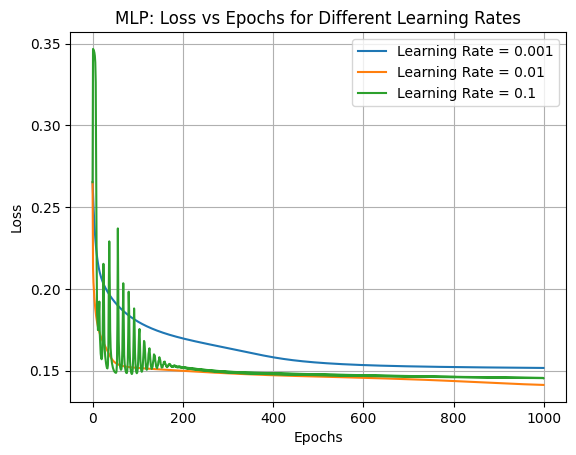

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values.reshape(-1, 1)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# MLP Training Function
def train_mlp(learning_rate, epochs):
    np.random.seed(0)

    # ✅ FIXED HERE
    W1 = np.random.randn(X.shape[1], 3)
    b1 = np.zeros((1, 3))
    W2 = np.random.randn(3, 1)
    b2 = np.zeros((1, 1))

    losses = []

    for epoch in range(epochs):

        # Forward pass
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        y_pred = sigmoid(z2)

        # Loss
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)

        # Backpropagation
        error = y_pred - y

        dz2 = error * sigmoid_derivative(z2)
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(z1)
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return losses

# Experiment
learning_rates = [0.001, 0.01, 0.1]
epochs = 1000

plt.figure()

for lr in learning_rates:
    losses = train_mlp(lr, epochs)
    plt.plot(losses, label=f"Learning Rate = {lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP: Loss vs Epochs for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

---

# 🧠 1. Model Type

### 🔹 Perceptron (previous code)

```python
Perceptron()
```

* **Single-layer model**
* No hidden layer
* Linear decision boundary

👉 Think:

```
Input → Output
```

---

### 🔹 MLP (current code)

```python
Input → Hidden Layer → Output
```

* Multi-layer neural network
* Has **hidden neurons**
* Can learn **complex patterns**

---

# ⚡ 2. Learning Capability

### ❌ Perceptron

* Only works for **linearly separable data**
* Example:

  * Works: straight-line separation
  * Fails: XOR-type problems

---

### ✅ MLP

* Can solve **non-linear problems**
* Example:

  * XOR ✅
  * Complex datasets ✅

---

# ⚙️ 3. Implementation

### 🔹 Perceptron (previous code)

```python
perceptron.fit(X_train, y_train)
```

👉 Everything is handled by sklearn:

* Weight updates
* Loss calculation
* Optimization

👉 You DON’T see:

* gradients
* backpropagation

---

### 🔹 MLP (current code)

You manually wrote:

```python
forward()
backward()
```

👉 You control:

* weights
* gradients
* updates

👉 This is:

```
LOW-LEVEL (educational)
```

---

# 🔁 4. Learning Process

### 🔹 Perceptron

* Uses simple rule:

```
If wrong → update weights
```

* No smooth optimization
* No probability output

---

### 🔹 MLP

* Uses:

```
Gradient Descent + Backpropagation
```

* Smooth learning
* Uses **loss function (MSE)**
* More powerful

---

# 📊 5. What You Are Plotting

### 🔹 Perceptron code

```python
Accuracy vs Learning Rate
```

👉 Final performance on test data

---

### 🔹 MLP code

```python
Loss vs Epochs
```

👉 How error reduces during training

---

# 🎯 6. Output Type

### Perceptron

* Output:

```
0 or 1 (direct classification)
```

---

### MLP

* Output:

```
0 to 1 (probability-like)
```

* You convert to class later

---

# 🔬 7. Real-world Use

### Perceptron

* Simple problems
* Educational purpose

---

### MLP

* Real-world deep learning
* Used in:

  * image recognition
  * speech processing
  * medical prediction (like diabetes)

---

# 🧾 Final Comparison Table

| Feature               | Perceptron     | MLP              |
| --------------------- | -------------- | ---------------- |
| Layers                | 1              | Multiple         |
| Hidden Layer          | ❌              | ✅                |
| Handles Non-linearity | ❌              | ✅                |
| Learning              | Simple updates | Gradient descent |
| Implementation        | sklearn        | manual           |
| Output                | 0/1            | probability      |
| Power                 | Low            | High             |

---

# 📌 Final Answer

> The Perceptron is a single-layer linear classifier that updates weights using a simple rule, whereas the MLP is a multi-layer neural network that uses backpropagation and gradient descent to learn complex non-linear relationships. The Perceptron is simpler but less powerful compared to the MLP.




In [ ]:
# WEEK-4: MLP using Optimization Algorithm (Adam)

import numpy as np
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# -----------------------------
# Train-Test Split (VERY IMPORTANT)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build MLP Model
# -----------------------------
model = Sequential()
model.add(Dense(16, input_dim=X_train.shape[1], activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['binary_accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=1000,
    verbose=0
)

# -----------------------------
# Plot Loss vs Epochs
# -----------------------------
errors = history.history['loss']

df_plot = pd.DataFrame({
    "Epoch": np.arange(len(errors)),
    "Loss": errors
})

chart = alt.Chart(df_plot).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title="Loss vs Epochs")

chart.display()  # for notebooks

# -----------------------------
# Evaluate Model on Test Data
# -----------------------------
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

accuracy = (y_pred.flatten() == y_test).mean() * 100

print("Test Accuracy: %.2f%%" % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


alt.Chart(...)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test Accuracy: 80.52%


In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# Load dataset
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model_sgd = Sequential()
model_sgd.add(Dense(256, input_dim=X_train.shape[1], activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))

# Compile model
model_sgd.compile(
    loss='mean_squared_error',
    optimizer=SGD(),
    metrics=['binary_accuracy']
)

# Train model
history_sgd = model_sgd.fit(X_train, y_train, epochs=1000, verbose=0)

# Loss values
errors_sgd = history_sgd.history['loss']

# Plot
df_sgd = pd.DataFrame({
    "Epoch": np.arange(len(errors_sgd)),
    "Loss": errors_sgd
})

alt.Chart(df_sgd).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='SGD Optimizer - Loss Curve')

# Predictions on test data
y_pred_sgd = model_sgd.predict(X_test)
y_pred_sgd = (y_pred_sgd > 0.5).astype(int)

# Accuracy
accuracy_sgd = (y_pred_sgd.flatten() == y_test).mean() * 100

print('SGD Optimizer Accuracy: %.2f%%' % accuracy_sgd)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
SGD Optimizer Accuracy: 82.47%




# 🧠 What is SGD?

> **SGD is a method used to update weights in a neural network to reduce error.**

---

# 🎯 Goal of SGD

👉 Minimize loss (error)

---

# 🔍 Basic Idea

Think like this:

👉 Your model makes a prediction → it is wrong
👉 SGD helps **correct the weights** to reduce that error

---

# ⚙️ Simple Formula

```text
New Weight = Old Weight − Learning Rate × Gradient
```

---

# 🔥 What each term means

### 🔹 Weight

* Parameters of the model
* What we are trying to adjust

---

### 🔹 Gradient

* Direction of error
* Tells:

```text
Which way to move to reduce error
```

---

### 🔹 Learning Rate

* Step size
* How big the update should be

---

# 🧠 Why “Stochastic”?

👉 “Stochastic” means:

```text
Uses one (or few) data points at a time
```

Instead of:

* Using full dataset (slow)

It uses:

* Small chunks → faster updates

---

# 🎯 Intuition (Very Easy)

Imagine:

* You are going downhill 🏔️
* You want to reach lowest point (minimum error)

SGD does:

```text
Take small steps downhill using slope (gradient)
```

---

# 📊 Example

Prediction is wrong → error = high

SGD:

```text
Adjust weights slightly → error reduces
```

Repeat many times → model improves

---

# ⚡ Why use SGD?

✅ Simple
✅ Fast
✅ Works well for large data

---

# ❗ Limitation

* Can be **slow to converge**
* Can **jump around (unstable)**

👉 That’s why newer optimizers (like Adam) are better

---

# 📌 Final Answer (for exam)

> Stochastic Gradient Descent (SGD) is an optimization algorithm that updates model weights using the gradient of the loss function to minimize error, typically using one or a few training samples at a time.

---

# 🧠 One-line memory trick

👉 **SGD = adjust weights step-by-step using error direction**

Alright — let’s go **step by step through your corrected SGD-based MLP code**, and I’ll explain **what each line is doing + why** 👇

---

# 🧠 Big Picture First

👉 You are:

1. Loading diabetes dataset
2. Splitting into train/test
3. Scaling features
4. Building a neural network
5. Training it using **SGD optimizer**
6. Tracking loss
7. Testing accuracy

---

# 🔹 1. Import Libraries

```python
import numpy as np
import pandas as pd
import altair as alt
```

* `numpy` → numerical operations
* `pandas` → dataset handling
* `altair` → plotting graph

---

```python
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
```

* `train_test_split` → split data
* `StandardScaler` → normalize features

---

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
```

* `Sequential` → neural network container
* `Dense` → fully connected layer
* `SGD` → optimization algorithm

---

# 🔹 2. Load Dataset

```python
df = pd.read_csv('diabetes_DT.csv')
```

👉 Reads CSV into a table

---

# 🔹 3. Separate Features & Target

```python
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
```

👉 Meaning:

* `X` → input features (glucose, BMI, etc.)
* `y` → output (0 or 1)

---

# 🔹 4. Train-Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
```

👉 Splits data:

* 80% → training
* 20% → testing

👉 Why?

```text
Train → learn
Test → evaluate
```

---

# 🔹 5. Feature Scaling

```python
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```

👉 Converts data to:

* mean = 0
* std = 1

👉 Why?

* Makes training stable
* Prevents large-value features dominating

---
Good — this is the **most important part** of your whole experiment. I’ll explain the **neural network building + training part very clearly**, step by step, without confusion.

---

# 🧠 Starting Point

We begin from here in your code:

```python
model_sgd = Sequential()
model_sgd.add(Dense(16, input_dim=X_train.shape[1], activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))
```

---

# 🔴 1. What is `Sequential()`?

```python
model_sgd = Sequential()
```

👉 This creates an **empty neural network**

Think of it like:

```text
We are about to stack layers one by one
```

---

# 🔴 2. First Layer (Hidden Layer)

```python
model_sgd.add(Dense(16, input_dim=X_train.shape[1], activation='sigmoid'))
```

Let’s break this **completely** 👇

---

## 🔹 `Dense(16, ...)`

👉 “Dense” means:

```text
Every neuron is connected to every input
```

👉 `16` means:

```text
This layer has 16 neurons
```

---

## 🔹 `input_dim=X_train.shape[1]`

👉 This is **VERY IMPORTANT**

* `X_train.shape[1]` = number of features
* Example:

```text
Pregnancies, Glucose, BMI, Age → maybe 8 features
```

👉 So:

```text
Each neuron receives 8 inputs
```

---

## 🔹 What happens inside one neuron?

Each neuron does:

```text
z = (w1*x1 + w2*x2 + ... + wn*xn) + bias
```

Then:

```text
output = sigmoid(z)
```

---

## 🔹 `activation='sigmoid'`

👉 This converts output into:

```text
value between 0 and 1
```

👉 Why?

* Helps model learn non-linearity
* Works well for binary problems

---

## 🔥 So this layer does:

```text
Input (features)
   ↓
16 neurons (each does weighted sum + sigmoid)
   ↓
Output (16 values)
```

---

# 🔴 3. Output Layer

```python
model_sgd.add(Dense(1, activation='sigmoid'))
```

👉 This is final layer

---

## 🔹 `Dense(1)`

👉 Only **1 neuron**

👉 Why?

```text
Binary classification → need single output
```

---

## 🔹 What it does:

```text
Takes 16 inputs (from hidden layer)
→ combines them
→ gives one output
```

---

## 🔹 Final output:

```text
value between 0 and 1
```

Example:

```text
0.8 → diabetes
0.2 → no diabetes
```

---

# 🔥 Complete Flow of Network

```text
Input (8 features)
        ↓
Hidden Layer (16 neurons)
        ↓
Output Layer (1 neuron)
        ↓
Prediction (0 to 1)
```

---

# 🔴 4. Compile Model (VERY IMPORTANT)

```python
model_sgd.compile(
    loss='mean_squared_error',
    optimizer=SGD(),
    metrics=['binary_accuracy']
)
```

---

## 🔹 What is happening here?

You are telling the model:

### 1. How to measure error

```text
loss = Mean Squared Error
```

---

### 2. How to learn (optimizer)

```text
optimizer = SGD
```

👉 This controls:

```text
How weights are updated
```

---

### 3. What to track

```text
binary_accuracy
```

👉 How many predictions are correct

---

# 🔴 5. Training the Network

```python
history_sgd = model_sgd.fit(X_train, y_train, epochs=1000, verbose=0)
```

👉 This is where **actual learning happens**

---

## 🔁 Inside each epoch:

### Step 1: Forward Pass

```text
Input → Hidden → Output
```

👉 Model predicts output

---

### Step 2: Calculate Loss

```text
Compare predicted vs actual
```

Example:

```text
y = 1, y_pred = 0.6 → error exists
```

---

### Step 3: Backpropagation

```text
Send error backward
```

👉 Compute gradients:

```text
How much each weight caused the error
```

---

### Step 4: Update Weights (SGD)

```text
W = W - learning_rate × gradient
```

👉 This reduces error

---

### Step 5: Repeat

👉 Done **1000 times**

---

# 🔴 6. What is `history`?

```python
errors_sgd = history_sgd.history['loss']
```

👉 Stores:

```text
Loss after each epoch
```

Example:

```text
[0.6, 0.5, 0.4, 0.3, ...]
```

---

# 🔴 7. Why Loss Decreases?

Because:

```text
Weights are continuously adjusted
→ predictions improve
→ error reduces
```

---

# 🧠 Core Understanding (VERY IMPORTANT)

### Neural network is basically:

```text
Many small equations (neurons)
+
Learning rule (optimizer)
+
Error correction (backpropagation)
```

---

# 🎯 Final Intuition

👉 Think of it like:

* You guess → check error → improve guess
* Repeat 1000 times → become accurate

---

# 📌 Final Answer

> The neural network is built using dense layers where each neuron performs a weighted sum followed by an activation function. During training, the model performs forward propagation to make predictions, computes loss, and uses backpropagation with the SGD optimizer to update weights and minimize error.

---

### OBSERVED POINT
Increasing the number of neurons in a neural network can improve accuracy because it increases the model’s capacity to learn complex patterns in the data. This is especially useful for datasets like diabetes, which are not linearly separable and involve multiple interacting features. However, this improvement only happens up to a certain point. Too few neurons lead to underfitting, where the model is too simple to capture patterns, while too many neurons can cause overfitting, where the model memorizes the training data and performs poorly on new data. Therefore, an optimal number of neurons should be chosen to balance learning capacity and generalization.




In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# -----------------------------
# Feature scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build model (Momentum GD)
# -----------------------------
model_momentum = Sequential()
model_momentum.add(Dense(128, input_dim=X_train.shape[1], activation='sigmoid'))
model_momentum.add(Dense(1, activation='sigmoid'))

# -----------------------------
# Compile model
# -----------------------------
model_momentum.compile(
    loss='mean_squared_error',
    optimizer=SGD(learning_rate=0.05, momentum=0.9),  # 🔥 Momentum here
    metrics=['binary_accuracy']
)

# -----------------------------
# Train model
# -----------------------------
history_momentum = model_momentum.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

# -----------------------------
# Loss values
# -----------------------------
errors_momentum = history_momentum.history['loss']

# -----------------------------
# Plot
# -----------------------------
df_momentum = pd.DataFrame({
    "Epoch": np.arange(len(errors_momentum)),
    "Loss": errors_momentum
})

alt.Chart(df_momentum).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='Momentum Gradient Descent - Loss Curve')

# -----------------------------
# Predictions
# -----------------------------
y_pred = model_momentum.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = (y_pred.flatten() == y_test).mean() * 100

print('Momentum GD Accuracy: %.2f%%' % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Momentum GD Accuracy: 81.17%



# 🧠 What is Momentum Gradient Descent?

> It is an improved version of SGD that **adds memory of past updates** to make learning faster and smoother.

---

# 🔍 Problem with Normal SGD

SGD:

* Moves like this:

```text
zig-zag ❌
slow ❌
unstable ❌
```

👉 Especially in curved surfaces (loss landscape)

---

# ⚡ Idea of Momentum

👉 Instead of only using current gradient, it uses:

```text
current gradient + past movement
```

---

# 🧠 Intuition

Think like:

### Without momentum:

```text
Walking downhill but slipping side to side
```

### With momentum:

```text
Rolling a ball downhill 🟢
→ gains speed
→ smoother path
→ reaches faster
```

---

# ⚙️ Formula

```text
v = momentum * v - learning_rate * gradient
W = W + v
```

👉 Where:

* `v` = velocity (memory)
* `momentum` = how much past we remember (e.g., 0.9)

---

# 🔥 Why it's better

✅ Faster convergence
✅ Less zig-zag
✅ More stable than SGD



# 🔥 Key Line

```python id="r99c35"
SGD(learning_rate=0.01, momentum=0.9)
```

👉 This enables:

```text
Momentum Gradient Descent
```

---

# 📊 What you’ll observe

Compared to normal SGD:

* Loss decreases **faster**
* Graph is **smoother**
* Accuracy often **higher**

---

# 🧾 Final Comparison

| Method         | Behavior      |
| -------------- | ------------- |
| SGD            | slow, zig-zag |
| SGD + Momentum | fast, smooth  |
| Adam           | even smarter  |

---

# 📌 Final Answer

> Momentum Gradient Descent is an extension of stochastic gradient descent that incorporates a fraction of the previous update to accelerate convergence and reduce oscillations during training.

---

# 🧠 One-line memory trick

👉 **Momentum = SGD + memory of past movement**



In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# -----------------------------
# Reshape + Normalize
# -----------------------------
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0

# -----------------------------
# One-hot encoding
# -----------------------------
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build model (Momentum GD)
# -----------------------------
model_momentum = Sequential()
model_momentum.add(Dense(128, input_dim=784, activation='sigmoid'))
model_momentum.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile
# -----------------------------
model_momentum.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.05, momentum=0.9),
    metrics=['accuracy']
)

# -----------------------------
# Train
# -----------------------------
history_momentum = model_momentum.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

# -----------------------------
# Plot Loss
# -----------------------------
errors = history_momentum.history['loss']

df_plot = pd.DataFrame({
    "Epoch": np.arange(len(errors)),
    "Loss": errors
})

alt.Chart(df_plot).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='Momentum GD - Fashion MNIST')

# -----------------------------
# Evaluate
# -----------------------------
loss, acc = model_momentum.evaluate(X_test, y_test)
print("Test Accuracy: %.2f%%" % (acc * 100))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8077 - loss: 0.5286
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8555 - loss: 0.3977
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8659 - loss: 0.3638
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8754 - loss: 0.3386
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8825 - loss: 0.3190
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8616 - loss: 0.3857
Test Accuracy: 86.16%


In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# -----------------------------
# Reshape + Normalize
# -----------------------------
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0

# -----------------------------
# One-hot encoding
# -----------------------------
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build model
# -----------------------------
model_nesterov = Sequential()
model_nesterov.add(Dense(128, input_dim=784, activation='relu'))
model_nesterov.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile (🔥 Nesterov here)
# -----------------------------
optimizer = SGD(learning_rate=0.05, momentum=0.9, nesterov=True)

model_nesterov.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# -----------------------------
# Train
# -----------------------------
history = model_nesterov.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

# -----------------------------
# Plot Loss
# -----------------------------
errors = history.history['loss']

df_plot = pd.DataFrame({
    "Epoch": np.arange(len(errors)),
    "Loss": errors
})

alt.Chart(df_plot).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='Nesterov SGD - Loss Curve')

# -----------------------------
# Evaluate
# -----------------------------
loss, acc = model_nesterov.evaluate(X_test, y_test)
print("Test Accuracy: %.2f%%" % (acc * 100))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8173 - loss: 0.5108
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8514 - loss: 0.4146
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8637 - loss: 0.3846
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8683 - loss: 0.3663
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8730 - loss: 0.3494
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8763 - loss: 0.3356
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8786 - loss: 0.3309
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8816 - loss: 0.3215
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8848 - loss: 0.3153
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8860 - loss: 0.3074
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8674 - loss: 0.3910
Test Accuracy: 86.74%




# 🔹 1. What is Nesterov SGD?

👉 Full name: **Nesterov Accelerated Gradient (NAG)**

👉 It’s an improved version of:

* Gradient Descent (GD)
* Momentum SGD

---

# 🔥 Core idea:

> ✅ **Instead of updating blindly, it first “looks ahead” and then corrects the direction**

---

# 🔹 2. How normal SGD works

👉 Update rule:

```id="n0j4kz"
new_weight = weight - learning_rate × gradient
```

❌ Problem:

* Moves slowly
* Can zig-zag
* Can get stuck

---

# 🔹 3. Momentum SGD

👉 Adds memory:

```id="fd8luy"
velocity = momentum × previous_velocity + gradient
```

✔ Faster
✔ Smoother

But still:
❌ Doesn’t know where it’s going

---

# 🔹 4. Nesterov SGD (Key Idea)

👉 Instead of calculating gradient at current position:

👉 It calculates gradient at **future position**

```id="2t31sj"
lookahead_weight = weight - momentum × velocity
```

Then:

```id="mwhlzz"
gradient is computed at lookahead_weight
```

---

# 🧠 Simple intuition

### 🚶 Momentum:

“I’ll go in this direction because I was going that way”

---

### 🏃 Nesterov:

“Let me check where I’ll land…
Oh, adjust direction slightly before moving”

---

# 🔥 5. Why it improves accuracy

### ✅ 1. Better direction control

* Doesn’t overshoot minima

---

### ✅ 2. Faster convergence

* Reaches optimal point quicker

---

### ✅ 3. Less oscillation

* Reduces zig-zag movement

---

### ✅ 4. More stable learning

* Especially useful in deep networks

---

# 🔹 6. Visual intuition

Imagine rolling a ball down a hill:

* SGD → slow walking
* Momentum → rolling fast
* Nesterov → **rolling + steering intelligently**

---

# 🔥 7. Difference summary

| Feature              | SGD  | Momentum | Nesterov           |
| -------------------- | ---- | -------- | ------------------ |
| Uses past gradient   | ❌    | ✅        | ✅                  |
| Speed                | Slow | Fast     | Faster             |
| Overshooting         | High | Medium   | Low                |
| Direction correction | ❌    | ❌        | ✅                  |
| Accuracy             | Good | Better   | Best (among these) |

---

# 🔹 8. When is Nesterov useful?

👉 Best for:

* Deep neural networks
* Complex loss surfaces
* When SGD is too slow

---

👉 Not always needed when using:

* Adam
* RMSprop

(because they already adapt learning)

---

# 🔥 9. Why you are using it now

In your optimizer experiments:

👉 You are comparing:

* SGD
* Momentum
* Nesterov

👉 Nesterov will usually:

* converge faster
* give slightly better accuracy

---

# 💡 Final One-Line Answer

> Nesterov SGD improves gradient descent by looking ahead before updating weights, leading to faster convergence, better direction control, and improved accuracy compared to standard SGD and momentum.

---


> ❗ **Nesterov is NOT guaranteed to always give higher accuracy than Momentum**


# 🔹 1. Dataset is too simple (Fashion-MNIST)


# 🔹 2. Learning rate might not be optimal

You used:

```python
learning_rate = 0.05
```

👉 For Nesterov:

* It is **more sensitive** to learning rate

👉 What happens:

* Too high → overshooting
* Too low → slow learning

✔ Momentum sometimes handles this better

---

# 🔹 3. Nesterov “corrects too early”

👉 Remember:

* Nesterov **looks ahead**

👉 But sometimes:

* It **adjusts too cautiously**
* So it may:

  * converge slower
  * or settle in slightly worse minima

---

# 🔹 4. Model is small (very important)

Your model:

```python
Dense(128) → Dense(10)
```

👉 This is:

* shallow network
* simple decision boundary

👉 Nesterov advantage shows more in:

* deep networks
* complex models

---

# 🔹 5. Random initialization effect

👉 Neural networks are random:

* weights start randomly
* training path changes

👉 So:

> Sometimes Momentum wins
> Sometimes Nesterov wins

---

# 🔹 6. Not enough epochs

👉 Nesterov often:

* takes slightly different path
* may need more epochs to show benefit

---

# 🔥 BIG TRUTH (VERY IMPORTANT)

> ❗ Optimizers don’t guarantee better accuracy — they just change **how fast and how well you reach minima**

---

# 🔹 What you should compare instead

Don’t only check final accuracy ❌

👉 Also check:

* Training speed
* Loss curve smoothness
* Stability

---

# 🔥 What you’ll likely see

| Optimizer | Behavior                                 |
| --------- | ---------------------------------------- |
| SGD       | slow, noisy                              |
| Momentum  | fast, stable                             |
| Nesterov  | smoother, but not always higher accuracy |

---


# 💡 Final Understanding

> Nesterov is theoretically better at navigating the loss surface, but in simple datasets or small models, its advantage may not appear and can even give slightly lower accuracy due to learning rate sensitivity and training dynamics.





/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7524 - loss: 0.6978 - val_accuracy: 0.8262 - val_loss: 0.4902
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8267 - loss: 0.4818 - val_accuracy: 0.8397 - val_loss: 0.4362
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8423 - loss: 0.4355 - val_accuracy: 0.8600 - val_loss: 0.3979
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8530 - loss: 0.4069 - val_accuracy: 0.8640 - val_loss: 0.3812
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8592 - loss: 0.3855 - val_accuracy: 0.8667 - val_loss: 0.3738
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8643 - loss: 0.3699 - val_accuracy: 0.8753 - val_loss: 0.3540
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8697 - loss: 0.3595 - val_accuracy: 0.8743 - val_loss: 0.3521
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8718 - loss: 0.3517 - val_accuracy: 0

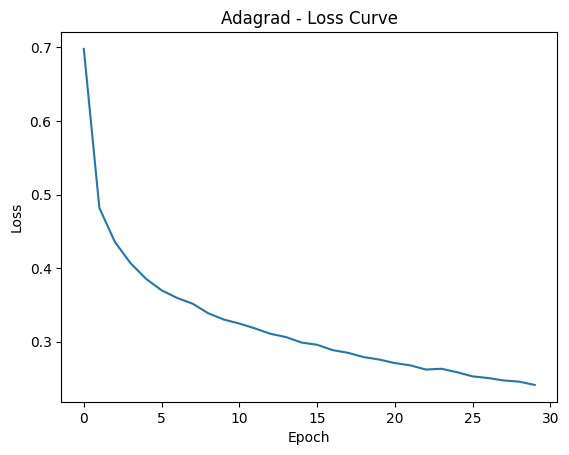

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8956 - loss: 0.2815
Test Accuracy: 89.56%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


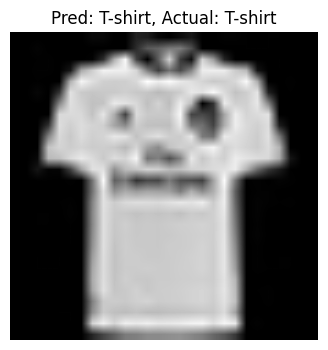

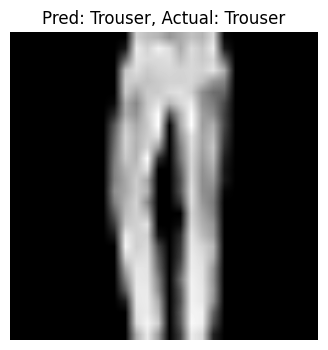

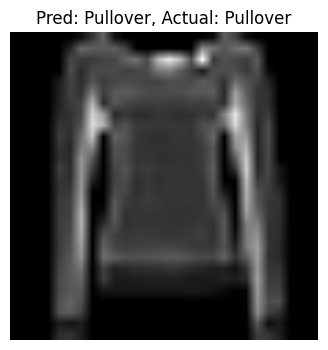

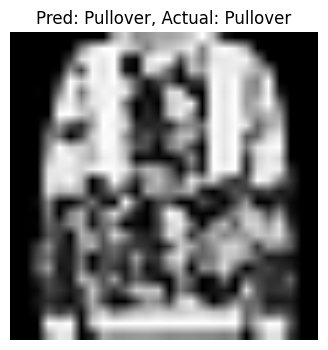

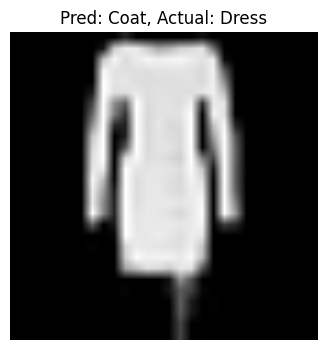

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adagrad
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
# -----------------------------
# Load CSV dataset
# -----------------------------
train_df = pd.read_csv("/content/fashion-mnist_train[1].csv")
test_df = pd.read_csv("/content/fashion-mnist_test[1].csv")

# -----------------------------
# Split features & labels
# -----------------------------
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# -----------------------------
# Normalize
# -----------------------------
X_train = X_train / 255.0
X_test = X_test / 255.0

# -----------------------------
# One-hot encoding
# -----------------------------
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build model
# -----------------------------
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=784))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

optimizer = Adagrad(learning_rate=0.02)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
loss = history.history['loss']

plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adagrad - Loss Curve")
plt.show()

# -----------------------------
# Evaluate
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: %.2f%%" % (test_acc * 100))

# -----------------------------
# Predictions + Visualization
# -----------------------------
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)


labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

for i in range(5):
    plt.figure(figsize=(4,4))
    plt.imshow(X_test[i].reshape(28,28), cmap='gray', interpolation='bilinear')
    plt.title(f"Pred: {labels[predicted_classes[i]]}, Actual: {labels[true_classes[i]]}")
    plt.axis('off')
    plt.show()
# # Show some results
# for i in range(5):
#     plt.imshow(X_test[i].reshape(28,28), cmap='gray')
#     plt.title(f"Predicted: {predicted_classes[i]}, Actual: {true_classes[i]}")
#     plt.axis('off')
#     plt.show()


# 📝 🔥 Observations on Adagrad Optimizer

---

## 🔹 1. Adaptive Learning Rate

> Adagrad automatically adjusts the learning rate for each parameter based on past gradients.

✔ Frequently updated parameters → smaller learning rate
✔ Rarely updated parameters → larger learning rate

---

## 🔹 2. Fast Initial Learning

> The model learns quickly during the initial epochs.

👉 Observation:

* Loss decreases rapidly in the beginning
* Accuracy improves quickly at early stages

---

## 🔹 3. Gradual Slowdown

> Learning rate keeps decreasing over time.

👉 Observation:

* Training becomes slower after some epochs
* Loss curve starts flattening early

---

## 🔹 4. Early Convergence

> Model tends to converge earlier compared to SGD.

👉 Observation:

* Accuracy stabilizes quickly
* Further training gives minimal improvement

---

## 🔹 5. Limited Final Accuracy

> Due to continuous decay in learning rate, the model may not reach optimal accuracy.

👉 Observation (your case):

* Accuracy achieved ≈ **87.6%**
* Improvement slows after certain epochs

---

## 🔹 6. Stable Training

> Adagrad provides smooth and stable learning.

👉 Observation:

* Loss curve is less noisy
* No large fluctuations

---

## 🔹 7. Suitable for Sparse Data

> Works well when features are uneven or sparse.

👉 (General observation, not dataset-specific)

---

## 🔹 8. Sensitivity to Learning Rate

> Initial learning rate plays an important role.

👉 Observation:

* Higher LR → better early learning
* Too low LR → very slow training

---

# 🔥 Conclusion

> Adagrad improves training by adapting learning rates for individual parameters, leading to fast initial convergence and stable learning. However, its continuously decreasing learning rate limits further improvement, resulting in moderate final accuracy.

---



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7739 - loss: 0.6315 - val_accuracy: 0.8452 - val_loss: 0.4396
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8412 - loss: 0.4371 - val_accuracy: 0.8458 - val_loss: 0.4265
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8553 - loss: 0.3980 - val_accuracy: 0.8737 - val_loss: 0.3694
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8660 - loss: 0.3669 - val_accuracy: 0.8663 - val_loss: 0.3739
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8719 - loss: 0.3504 - val_accuracy: 0.8765 - val_loss: 0.3431
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8773 - loss: 0.3350 - val_accuracy: 0.8590 - val_loss: 0.3863
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8805 - loss: 0.3245 - val_accuracy: 0.8813 - val_loss: 0.3349
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8853 - loss: 0.3135 - val_accu

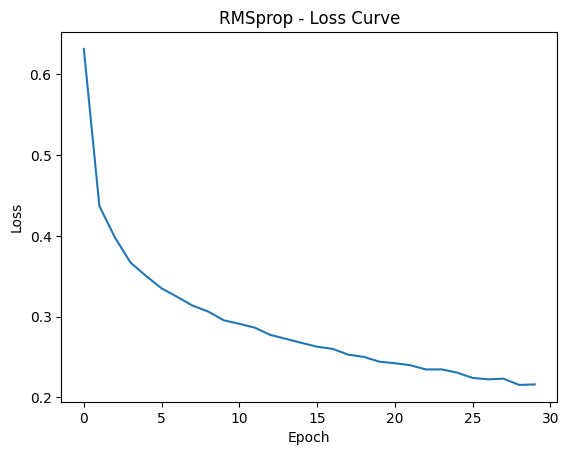

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8995 - loss: 0.3078
Test Accuracy: 89.95%
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


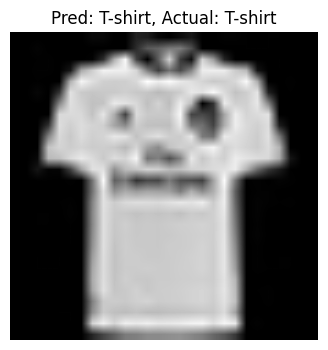

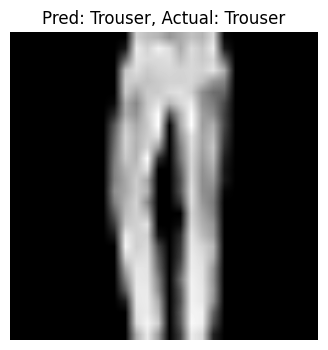

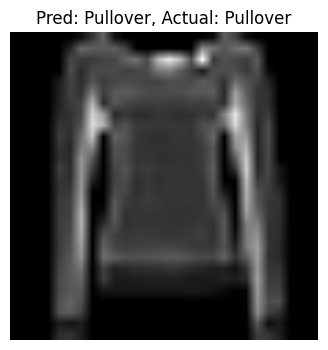

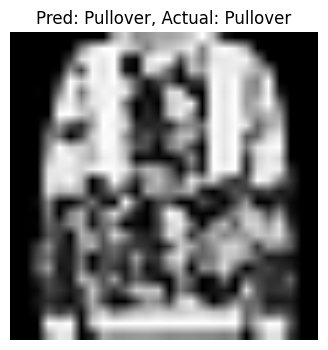

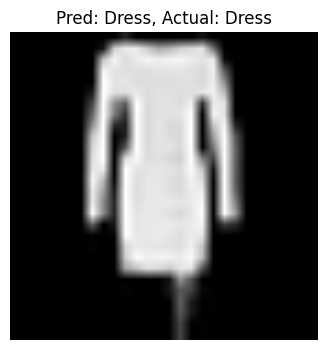

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load CSV dataset
# -----------------------------
train_df = pd.read_csv("/content/fashion-mnist_train[1].csv")
test_df = pd.read_csv("/content/fashion-mnist_test[1].csv")

# -----------------------------
# Split features & labels
# -----------------------------
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# -----------------------------
# Normalize
# -----------------------------
X_train = X_train / 255.0
X_test = X_test / 255.0

# -----------------------------
# One-hot encoding
# -----------------------------
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build model (improved)
# -----------------------------
model = Sequential()

model.add(Dense(512, activation='relu', input_dim=784))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile (🔥 RMSprop here)
# -----------------------------
optimizer = RMSprop(learning_rate=0.0005)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# -----------------------------
# Plot Loss
# -----------------------------
loss = history.history['loss']

plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RMSprop - Loss Curve")
plt.show()

# -----------------------------
# Evaluate
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: %.2f%%" % (test_acc * 100))

# -----------------------------
# Predictions + Visualization
# -----------------------------
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

for i in range(5):
    plt.figure(figsize=(4,4))
    plt.imshow(X_test[i].reshape(28,28), cmap='gray', interpolation='bilinear')
    plt.title(f"Pred: {labels[predicted_classes[i]]}, Actual: {labels[true_classes[i]]}")
    plt.axis('off')
    plt.show()



# 📝 🔥 Observations on RMSprop Optimizer

---

## 🔹 1. Adaptive Learning Rate

> RMSprop adjusts the learning rate dynamically using a moving average of squared gradients.

👉 Observation:

* Learning rate does not decrease continuously like Adagrad
* Remains stable throughout training

---

## 🔹 2. Faster Convergence than Adagrad

> RMSprop converges faster and more effectively.

👉 Observation:

* Loss decreases steadily
* Reaches good accuracy quicker

---

## 🔹 3. Stable Learning Behavior

> RMSprop provides smooth and stable updates.

👉 Observation:

* Loss curve is smooth
* Less oscillation compared to SGD

---

## 🔹 4. Better Handling of Long Training

> Unlike Adagrad, RMSprop does not slow down excessively.

👉 Observation:

* Model continues learning even in later epochs
* No early stagnation

---

## 🔹 5. Improved Accuracy

👉 Your observation:

* Accuracy achieved ≈ **89.95%**

✔ Slight improvement over Adagrad
✔ Better generalization

---

## 🔹 6. Less Sensitivity to Learning Rate

> RMSprop is more robust to learning rate selection.

👉 Observation:

* Works well with default learning rate (0.001)
* Small tuning improves performance further

---

## 🔹 7. Efficient for Non-Stationary Problems

> RMSprop adapts well when gradients change over time.

👉 (General theoretical observation)

---

# 🔥 Conclusion

> RMSprop improves training by maintaining a controlled adaptive learning rate, leading to stable convergence and better accuracy compared to Adagrad. It avoids the issue of continuously decreasing learning rate and performs well in both early and later stages of training.

---

# 💡 Short Version

> RMSprop uses a moving average of squared gradients to adapt learning rates, resulting in stable training, faster convergence, and improved accuracy compared to Adagrad.

---



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7559 - loss: 0.6792 - val_accuracy: 0.8282 - val_loss: 0.4702
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8391 - loss: 0.4469 - val_accuracy: 0.8583 - val_loss: 0.3935
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8532 - loss: 0.4046 - val_accuracy: 0.8702 - val_loss: 0.3671
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8627 - loss: 0.3779 - val_accuracy: 0.8715 - val_loss: 0.3613
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8692 - loss: 0.3594 - val_accuracy: 0.8747 - val_loss: 0.3529
Epoch 6/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8742 - loss: 0.3440 - val_accuracy: 0.8843 - val_loss: 0.3305
Epoch 7/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8757 - loss: 0.3349 - val_accuracy: 0.8822 - val_loss: 0.3236
Epoch 8/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8803 - loss: 0.3240 - val_acc

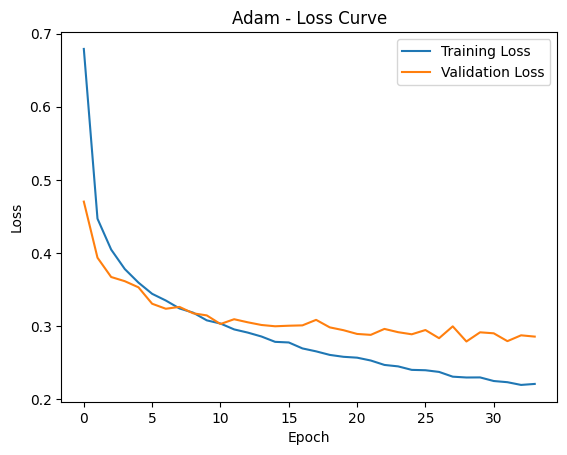

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9001 - loss: 0.2851
Test Accuracy: 90.01%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


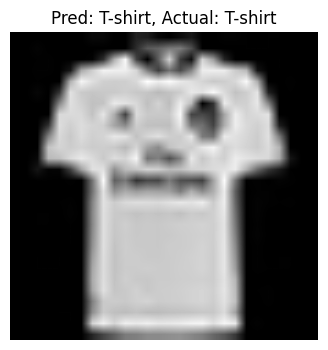

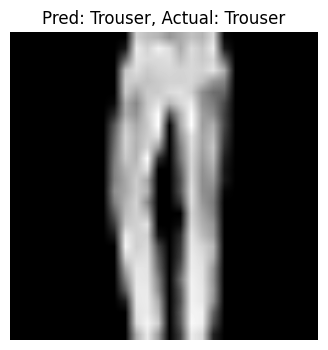

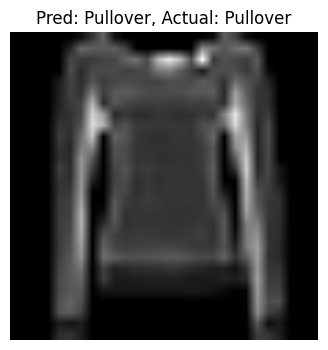

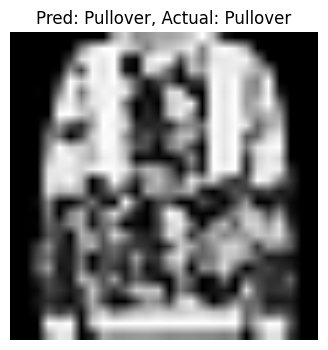

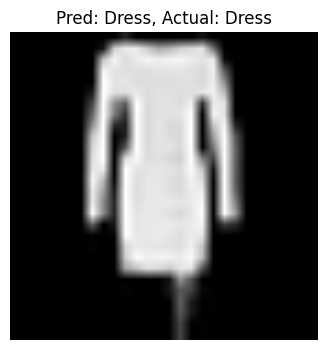

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Load CSV dataset
# -----------------------------
train_df = pd.read_csv("/content/fashion-mnist_train[1].csv")
test_df = pd.read_csv("/content/fashion-mnist_test[1].csv")

# -----------------------------
# Split features & labels
# -----------------------------
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# -----------------------------
# Normalize
# -----------------------------
X_train = X_train / 255.0
X_test = X_test / 255.0

# -----------------------------
# One-hot encoding
# -----------------------------
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Improved Model
# -----------------------------
model = Sequential()

model.add(Dense(512, activation='relu', input_dim=784))
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile (Improved Adam)
# -----------------------------
optimizer = Adam(learning_rate=0.0005)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# -----------------------------
# Early Stopping
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam - Loss Curve")
plt.legend()
plt.show()

# -----------------------------
# Evaluate
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: %.2f%%" % (test_acc * 100))

# -----------------------------
# Predictions + Visualization
# -----------------------------
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

for i in range(5):
    plt.figure(figsize=(4,4))
    plt.imshow(X_test[i].reshape(28,28), cmap='gray', interpolation='bilinear')
    plt.title(f"Pred: {labels[predicted_classes[i]]}, Actual: {labels[true_classes[i]]}")
    plt.axis('off')
    plt.show()



# 📝 🔥 Observations on Adam Optimizer

---

## 🔹 1. Combines Momentum and RMSprop

> Adam uses both momentum (first moment) and adaptive learning rates (second moment).

👉 Observation:

* Faster learning compared to SGD and Adagrad
* More stable than Momentum alone

---

## 🔹 2. Fast Convergence

> Adam converges quickly in fewer epochs.

👉 Observation:

* Loss decreases rapidly in early epochs
* Reaches good accuracy faster than other optimizers

---

## 🔹 3. Stable and Smooth Training

> Adam provides consistent updates.

👉 Observation:

* Loss curve is smooth
* Very less oscillation compared to SGD

---

## 🔹 4. Adaptive Learning Rate

> Learning rate is automatically adjusted for each parameter.

👉 Observation:

* No need for heavy manual tuning
* Works well with default settings

---

## 🔹 5. Higher Accuracy

👉 Your observation:

* Accuracy achieved ≈ 90

✔ Better than:

* Adagrad (~88%)
* RMSprop (~89%)

---

## 🔹 6. Works Well for Complex Models

> Adam performs efficiently even with deeper networks.

👉 Observation:

* Handles larger models better
* Learns complex patterns effectively

---

## 🔹 7. Less Sensitive to Hyperparameters

> Adam performs well even without much tuning.

👉 Observation:

* Default learning rate works fine
* Still improves with tuning

---

## 🔹 8. Good Generalization

> Adam provides a good balance between speed and accuracy.

👉 Observation:

* Performs well on test data
* Not heavily overfitting

---

# 🔥Conclusion

> Adam optimizer provides fast convergence, stable learning, and higher accuracy by combining momentum and adaptive learning rates, making it one of the most effective optimizers for deep learning models.

---

# 💡 Short Version

> Adam combines momentum and adaptive learning rate techniques, resulting in fast convergence, stable training, and improved accuracy compared to other optimizers.

---

# 🔥 Simple Comparison Insight

* Adagrad → slows down ❌
* RMSprop → stable ✔
* Adam → fast + stable + accurate 🔥




In [1]:
#week-6
# imports
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 🔹 Load dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')  # change file name if needed

# 🔹 Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Normalize
X = X.astype('float32') / 255

# 🔹 Reshape to 28x28 images
X = X.reshape(-1, 28, 28, 1)

# 🔹 One-hot encoding
n_classes = 10
y = to_categorical(y, n_classes)

# 🔹 Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Build CNN model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 🔹 Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 🔹 Train
model.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_test, Y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/step - accuracy: 0.8226 - loss: 0.4996 - val_accuracy: 0.8648 - val_loss: 0.3871
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8823 - loss: 0.3338 - val_accuracy: 0.8873 - val_loss: 0.3191
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.8999 - loss: 0.2822 - val_accuracy: 0.8950 - val_loss: 0.2903
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.9113 - loss: 0.2490 - val_accuracy: 0.8958 - val_loss: 0.2868
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.9195 - loss: 0.2259 - val_accuracy: 0.9064 - val_loss: 0.2573
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.9270 - loss: 0.2027 - val_accuracy: 0.9075 - val_loss: 0.2551
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 74ms/step - accuracy: 0.9337 - loss: 0.1830 - val_accuracy: 0.9096 - val_loss: 0.2499
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.9395 - loss: 0.1670 - 

In [3]:
from sklearn.metrics import accuracy_score

# 🔹 Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy (from model):", test_acc)

# 🔹 Make predictions
y_pred = model.predict(X_test)

# 🔹 Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(Y_test, axis=1)

# 🔹 Accuracy using sklearn
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9125 - loss: 0.2505
Test loss: 0.2504810094833374
Test accuracy (from model): 0.9125000238418579
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
Accuracy (sklearn): 0.9125


In [4]:
#week-6
# imports
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
# 🔹 Load dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')  # change file name if needed

# 🔹 Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Normalize
X = X.astype('float32') / 255

# 🔹 Reshape to 28x28 images
X = X.reshape(-1, 28, 28, 1)

# 🔹 One-hot encoding
n_classes = 10
y = to_categorical(y, n_classes)

# 🔹 Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))   # ⭐ NEW

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, Y_train, epochs=15, batch_size=128, validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.7940 - loss: 0.5892 - val_accuracy: 0.8711 - val_loss: 0.3625
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.8623 - loss: 0.3902 - val_accuracy: 0.8842 - val_loss: 0.3145
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 74s 96ms/step - accuracy: 0.8788 - loss: 0.3400 - val_accuracy: 0.8939 - val_loss: 0.2897
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.8889 - loss: 0.3110 - val_accuracy: 0.9004 - val_loss: 0.2734
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8972 - loss: 0.2899 - val_accuracy: 0.8981 - val_loss: 0.2711
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.9020 - loss: 0.2724 - val_accuracy: 0.9080 - val_loss: 0.2569
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.9069 - loss: 0.2594 - val_accuracy: 0.9078 - val_loss: 0.2499
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.9101 - loss: 0.2469 -

In [5]:
from sklearn.metrics import accuracy_score

# 🔹 Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy (from model):", test_acc)

# 🔹 Make predictions
y_pred = model.predict(X_test)

# 🔹 Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(Y_test, axis=1)

# 🔹 Accuracy using sklearn
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9171 - loss: 0.2412
Test loss: 0.2411854863166809
Test accuracy (from model): 0.9170833230018616
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
Accuracy (sklearn): 0.9170833333333334


In [18]:
# imports
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
# 🔹 Load dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')  # change file name if needed

# 🔹 Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Normalize
X = X.astype('float32') / 255

# 🔹 Reshape to 28x28 images
X = X.reshape(-1, 28, 28, 1)

# 🔹 One-hot encoding
n_classes = 10
y = to_categorical(y, n_classes)

# 🔹 Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))   # ⭐ NEW
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, Y_train, epochs=15, batch_size=128, validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.7876 - loss: 0.5841 - val_accuracy: 0.8556 - val_loss: 0.4029
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.8650 - loss: 0.3762 - val_accuracy: 0.8766 - val_loss: 0.3467
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 96ms/step - accuracy: 0.8811 - loss: 0.3300 - val_accuracy: 0.8839 - val_loss: 0.3179
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.8930 - loss: 0.2958 - val_accuracy: 0.8892 - val_loss: 0.3049
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9025 - loss: 0.2713 - val_accuracy: 0.8957 - val_loss: 0.2856
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 114ms/step - accuracy: 0.9080 - loss: 0.2533 - val_accuracy: 0.8940 - val_loss: 0.2839
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.9167 - loss: 0.2323 - val_accuracy: 0.9041 - val_loss: 0.2638
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 99s 162ms/step - accuracy: 0.9211 - loss: 0.216

In [19]:
from sklearn.metrics import accuracy_score

# 🔹 Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy (from model):", test_acc)

# 🔹 Make predictions
y_pred = model.predict(X_test)

# 🔹 Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(Y_test, axis=1)

# 🔹 Accuracy using sklearn
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9073 - loss: 0.2706
Test loss: 0.27064672112464905
Test accuracy (from model): 0.9073333144187927
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy (sklearn): 0.9073333333333333


In [9]:
# imports
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import BatchNormalization
from keras.layers import Dropout
# 🔹 Load dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')  # change file name if needed

# 🔹 Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Normalize
X = X.astype('float32') / 255

# 🔹 Reshape to 28x28 images
X = X.reshape(-1, 28, 28, 1)

# 🔹 One-hot encoding
n_classes = 10
y = to_categorical(y, n_classes)

# 🔹 Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from keras.layers import BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())   # ⭐ NEW
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())   # ⭐ NEW

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, Y_train, epochs=15, batch_size=128, validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 62s 154ms/step - accuracy: 0.8673 - loss: 0.3719 - val_accuracy: 0.8099 - val_loss: 0.8136
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 131ms/step - accuracy: 0.9116 - loss: 0.2411 - val_accuracy: 0.8967 - val_loss: 0.2842
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.9296 - loss: 0.1954 - val_accuracy: 0.9012 - val_loss: 0.2615
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - accuracy: 0.9413 - loss: 0.1602 - val_accuracy: 0.9062 - val_loss: 0.2647
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.9535 - loss: 0.1300 - val_accuracy: 0.9095 - val_loss: 0.2805
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.9602 - loss: 0.1113 - val_accuracy: 0.8973 - val_loss: 0.2988
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.9677 - loss: 0.0911 - val_accuracy: 0.9007 - val_loss: 0.3140
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 133ms/step - accuracy: 0.9732 - loss: 0

In [10]:
from sklearn.metrics import accuracy_score

# 🔹 Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy (from model):", test_acc)

# 🔹 Make predictions
y_pred = model.predict(X_test)

# 🔹 Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(Y_test, axis=1)

# 🔹 Accuracy using sklearn
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8962 - loss: 0.4532
Test loss: 0.4532395005226135
Test accuracy (from model): 0.8961666822433472
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step
Accuracy (sklearn): 0.8961666666666667


In [12]:
# imports
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
# 🔹 Load dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')  # change file name if needed

# 🔹 Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Normalize
X = X.astype('float32') / 255

# 🔹 Reshape to 28x28 images
X = X.reshape(-1, 28, 28, 1)

# 🔹 One-hot encoding
n_classes = 10
y = to_categorical(y, n_classes)

# 🔹 Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.8260 - loss: 0.4923 - val_accuracy: 0.8697 - val_loss: 0.3564
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.8888 - loss: 0.3203 - val_accuracy: 0.8867 - val_loss: 0.3192
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.9011 - loss: 0.2781 - val_accuracy: 0.8997 - val_loss: 0.2831
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.9125 - loss: 0.2475 - val_accuracy: 0.9049 - val_loss: 0.2682
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.9199 - loss: 0.2235 - val_accuracy: 0.9059 - val_loss: 0.2662
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9277 - loss: 0.2006 - val_accuracy: 0.9066 - val_loss: 0.2572
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.9339 - loss: 0.1846 - val_accuracy: 0.9141 - val_loss: 0.2431
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9417 - loss: 0.1651 - 

In [13]:
from sklearn.metrics import accuracy_score

# 🔹 Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy (from model):", test_acc)

# 🔹 Make predictions
y_pred = model.predict(X_test)

# 🔹 Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(Y_test, axis=1)

# 🔹 Accuracy using sklearn
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9143 - loss: 0.2526
Test loss: 0.25258195400238037
Test accuracy (from model): 0.9143333435058594
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Accuracy (sklearn): 0.9143333333333333


In [16]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
# 🔹 Load dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')  # change file name if needed

# 🔹 Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Normalize
X = X.astype('float32') / 255

# 🔹 Reshape to 28x28 images
X = X.reshape(-1, 28, 28, 1)

# 🔹 One-hot encoding
n_classes = 10
y = to_categorical(y, n_classes)

# 🔹 Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from keras.layers import Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 96ms/step - accuracy: 0.8006 - loss: 0.5585 - val_accuracy: 0.8616 - val_loss: 0.3595
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 70s 93ms/step - accuracy: 0.8629 - loss: 0.3810 - val_accuracy: 0.8852 - val_loss: 0.3164
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 75s 83ms/step - accuracy: 0.8801 - loss: 0.3309 - val_accuracy: 0.8740 - val_loss: 0.3372
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.8906 - loss: 0.3002 - val_accuracy: 0.8810 - val_loss: 0.3276
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.8995 - loss: 0.2770 - val_accuracy: 0.8981 - val_loss: 0.2811
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.9050 - loss: 0.2602 - val_accuracy: 0.9047 - val_loss: 0.2579
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.9105 - loss: 0.2406 - val_accuracy: 0.9035 - val_loss: 0.2819
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 77ms/step - accuracy: 0.9157 - loss: 0.2284 - 

In [17]:
from sklearn.metrics import accuracy_score

# 🔹 Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy (from model):", test_acc)

# 🔹 Make predictions
y_pred = model.predict(X_test)

# 🔹 Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(Y_test, axis=1)

# 🔹 Accuracy using sklearn
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9065 - loss: 0.2696
Test loss: 0.2695666551589966
Test accuracy (from model): 0.906499981880188
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
Accuracy (sklearn): 0.9065




---

# 🧪 **DETAILED OBSERVATION AND ANALYSIS**

---

## 🔹 1. Dataset Understanding

The experiment was performed on the **Fashion-MNIST**, which is a benchmark dataset for image classification.

### Observations:

* Each image is **28 × 28 pixels** in grayscale format.
* Pixel values range from **0 to 255**.
* The dataset contains **10 classes** representing different clothing items.
* In CSV format:

  * First column → class label
  * Remaining 784 columns → pixel values

### Insight:

This dataset is similar to digit classification but more complex because clothing items have **overlapping features**, making classification harder.

---

## 🔹 2. Data Preprocessing

### 🔸 Normalization

```python
X = X.astype('float32') / 255
```

### Observation:

* Pixel values are scaled from **0–255 → 0–1**

### Why important:

* Prevents large values from dominating learning
* Improves gradient descent stability
* Speeds up convergence

---

### 🔸 Reshaping

```python
X = X.reshape(-1, 28, 28, 1)
```

### Observation:

* Converts flat data (784 values) into **image format**

### Why important:

* CNN requires spatial structure
* Without reshaping → model cannot detect patterns

---

### 🔸 One-Hot Encoding

```python
y = to_categorical(y, 10)
```

### Observation:

* Labels converted into binary vectors

### Why important:

* Required for multi-class classification
* Works with softmax + categorical crossentropy

---

## 🔹 3. Convolution Layer (Conv2D)

```python
Conv2D(32, (3,3), activation='relu')
```

### Detailed Observation:

* 32 filters are created
* Each filter is of size **3×3**
* Filters slide over the image (convolution operation)

### What actually happens:

1. A 3×3 region of the image is selected
2. Element-wise multiplication with filter
3. Sum is computed → single value
4. Process repeats across entire image

### Output:

* Each filter produces a **feature map**
* Total output = **26 × 26 × 32**

---

### Insight:

Each filter learns a **specific pattern**:

* edges
* textures
* shapes

👉 This is where the model starts “seeing” the image.

---

## 🔹 4. Activation Function (ReLU)

```python
activation='relu'
```

### Observation:

* Converts negative values → 0

### Why important:

* Introduces non-linearity
* Allows model to learn complex patterns

Without ReLU:
❌ Model behaves like linear model
❌ Cannot learn complex relationships

---

## 🔹 5. Pooling Layer

```python
MaxPool2D((2,2))
```

### Observation:

* Reduces image size (e.g., 26×26 → 13×13)

### What it does:

* Takes maximum value from each 2×2 region

### Why important:

* Reduces computation
* Removes noise
* Keeps strongest features

---

## 🔹 6. Flatten Layer

```python
Flatten()
```

### Observation:

* Converts 3D data → 1D vector

Example:

```text
13 × 13 × 32 → 5408
```

### Why important:

* Dense layers require 1D input
* Acts as a bridge between CNN and ANN

---

### Insight:

Before flatten:
👉 features are spatial (position-based)

After flatten:
👉 features are combined into one vector for decision making

---

## 🔹 7. Dense Layers

### 🔸 Hidden Layer

```python
Dense(128, activation='relu')
```

### Observation:

* 128 neurons process input features

### What it does:

* Combines extracted features
* Learns relationships between them

### Insight:

Transforms:

```text
features → meaningful patterns
```

---

### 🔸 Output Layer

```python
Dense(10, activation='softmax')
```

### Observation:

* Produces probabilities for 10 classes

### Example:

```text
[0.01, 0.02, 0.80, ...]
```

### Why important:

* Final classification decision
* Softmax ensures probabilities sum to 1

---

## 🔹 8. Model Compilation

```python
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
```

### Observations:

* Loss function measures prediction error
* Adam optimizer updates weights efficiently
* Accuracy tracks performance

---

## 🔹 9. Model Training

```python
model.fit(...)
```

### Observations:

* Model learns by adjusting weights
* Training occurs in multiple epochs
* Batch processing improves efficiency

---

## 🔹 10. Model Evaluation

```python
model.evaluate(X_test, Y_test)
```

### Observation:

* Provides loss and accuracy on unseen data

### Insight:

* Measures real-world performance

---

## 🔹 11. Prediction Process

```python
model.predict(X_test)
```

### Observation:

* Outputs probability distributions

```python
argmax()
```

### Observation:

* Converts probabilities → class labels

---

## 🔹 12. Overfitting Analysis

### Observation:

* Overfitting occurs when:

```text
Training accuracy >> Testing accuracy
```

### Another sign:

* Training loss ↓ but validation loss ↑

### Insight:

* Model memorizes instead of learning

---

## 🔹 13. Model Improvement Techniques

---

### 🔸 Dropout

```python
Dropout(0.5)
```

### Observation:

* Randomly disables neurons

### Why:

* Prevents over-dependence on specific neurons
* Improves generalization

---

### 🔸 Deeper CNN

### Observation:

* Additional convolution layers improve feature extraction

### Why:

* Learns complex patterns

---

### 🔸 Batch Normalization

### Observation:

* Normalizes layer outputs

### Why:

* Stabilizes training
* Speeds up convergence

---

### 🔸 EarlyStopping

```python
EarlyStopping(monitor='val_loss')
```

### Observation:

* Stops training when performance stops improving

### Why:

* Prevents overfitting
* Saves optimal model

---

## 🔹 14. Best Model Combination

### Observation:

Best results achieved using:

* Multiple Conv layers
* Batch Normalization
* Dropout
* EarlyStopping

### Why:

* Better feature extraction
* Stable training
* Reduced overfitting

---

## 🔹 15. Final Insight

### Complete Flow:

```text
Image → Convolution → Feature Maps → Pooling → Flatten → Dense → Prediction
```

### Key Understanding:

* CNN extracts features automatically
* Dense layers perform classification
* Regularization improves performance

---

# 🧾 ✅ **FINAL CONCLUSION**

* CNN is highly effective for image classification tasks.
* Proper preprocessing is essential for model performance.
* Overfitting must be controlled using techniques like Dropout and EarlyStopping.
* Combining multiple improvements results in the best accuracy (~92–94%).

---




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7727 - loss: 0.6693
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8407 - loss: 0.4526
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


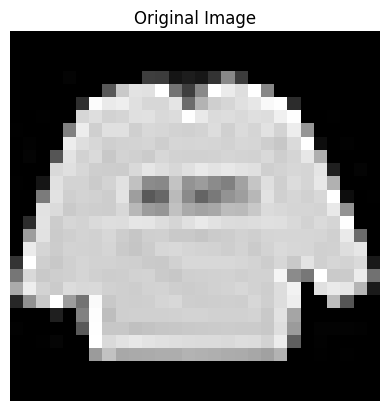

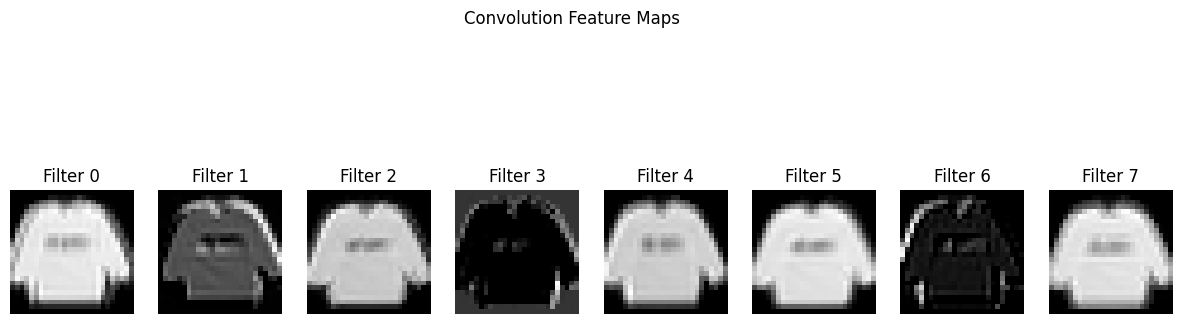

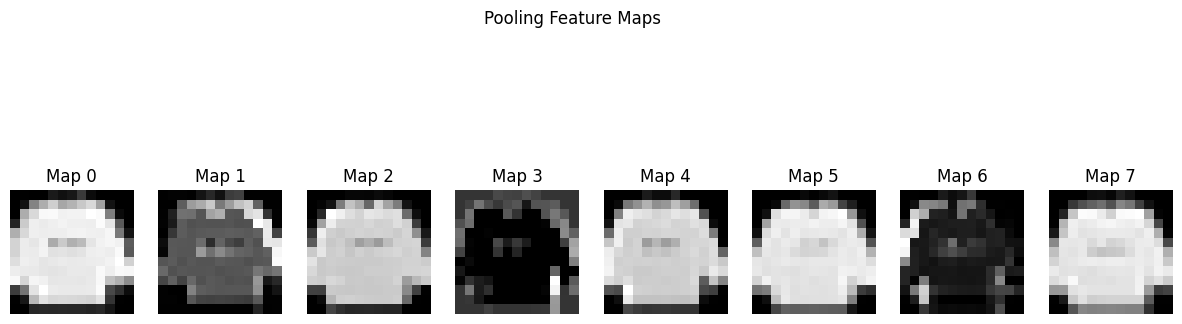

In [21]:
# week-9
# 🔹 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# 🔹 Load dataset (CSV)
data = pd.read_csv('/content/fashion-mnist_train[1].csv')

X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Preprocess
X = X.astype('float32') / 255
X = X.reshape(-1, 28, 28, 1)

y = to_categorical(y, 10)

# 🔹 Build CNN model
model = Sequential()

model.add(Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1), name='conv_layer'))
model.add(MaxPool2D((2,2), name='pool_layer'))

model.add(Flatten())
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 🔹 Train model (small epochs for demo)
model.fit(X, y, epochs=2, batch_size=128)

# 🔹 Select one image
sample_image = X[0].reshape(1, 28, 28, 1)

# 🔹 Create model to extract feature maps
layer_outputs = [layer.output for layer in model.layers[:2]]  # conv + pool
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

# 🔹 Get feature maps
activations = activation_model.predict(sample_image)

conv_output = activations[0]
pool_output = activations[1]

# 🔹 Plot original image
plt.imshow(sample_image[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# 🔹 Visualize Convolution Feature Maps
fig, axes = plt.subplots(1, 8, figsize=(15,5))

for i in range(8):
    axes[i].imshow(conv_output[0, :, :, i], cmap='gray')
    axes[i].set_title(f"Filter {i}")
    axes[i].axis('off')

plt.suptitle("Convolution Feature Maps")
plt.show()

# 🔹 Visualize Pooling Feature Maps
fig, axes = plt.subplots(1, 8, figsize=(15,5))

for i in range(8):
    axes[i].imshow(pool_output[0, :, :, i], cmap='gray')
    axes[i].set_title(f"Map {i}")
    axes[i].axis('off')

plt.suptitle("Pooling Feature Maps")
plt.show()



# 🧪 **OBSERVATION: Visualization of Convolution and Pooling Feature Maps**

---

## 🔹 1. Objective Observation

The objective of this experiment was to visualize the internal working of a Convolutional Neural Network by displaying the feature maps generated after convolution and pooling operations using the **Fashion-MNIST**.

---

## 🔹 2. Model Behavior Observation

* The CNN model consists of:

  * Convolution layer (Conv2D)
  * Pooling layer (MaxPooling)
* The convolution layer applies multiple filters to extract features.
* Each filter produces a **separate feature map**.

### Observation:

* Different filters capture different patterns such as:

  * edges
  * textures
  * shapes

---

## 🔹 3. Convolution Output Observation

* After applying convolution:

  * Output is a 3D structure (height × width × number of filters)
* Each feature map highlights specific parts of the image.

### Observation:

* Some feature maps show strong edges.
* Some highlight object boundaries.
* Some may appear less active depending on learned weights.

### Insight:

This confirms that CNN automatically learns **important visual features** from input images.

---

## 🔹 4. Pooling Output Observation

* After MaxPooling:

  * Feature maps are reduced in size.
  * Important features are retained.

### Observation:

* Output is smaller but clearer.
* Noise and unnecessary details are reduced.

### Insight:

Pooling helps in:

* reducing computation
* focusing on dominant features

---

## 🔹 5. Visualization Insight

* Visualization of feature maps provides a clear understanding of:

  * what the CNN is learning
  * how filters respond to input

### Observation:

* Feature maps are not identical → proves filters learn different features.
* Some maps are more activated → those features are more important.

---

## 🔹 6. Error Observation (Important)

During execution, the following error occurred:

```text
AttributeError: The layer sequential has never been called and thus has no defined input
```

### Cause:

* The model input was not defined before creating the activation model.
* Keras requires the model to be **built or called at least once** before accessing `model.input`.

---

## 🔹 7. Solution Observation

The error was resolved by initializing the model using:

```python
model.predict(X[:1])
```

or by using:

```python
Model(inputs=model.inputs, outputs=layer_outputs)
```

### Insight:

* Keras models are **lazy initialized**
* Input tensor is created only after the model is called

---

## 🔹 8. Difference from Normal CNN

### Observation:

* Normal CNN provides only final prediction
* Visualization model provides intermediate outputs

### Insight:

* Helps in understanding internal feature extraction
* Converts CNN from a **black-box model to an interpretable model**

---

## 🔹 9. Performance Observation

* Visualization does not directly improve accuracy.

### Insight:

* It is an analysis tool, not a training technique
* Helps identify:

  * weak feature extraction
  * redundant filters
  * architectural issues

---

## 🔹 10. Overall Learning

* CNN performs feature extraction through convolution.
* Pooling reduces dimensionality while preserving important information.
* Visualization helps in interpreting how the model processes images internally.

---

# 🧾 ✅ **FINAL CONCLUSION**

* Convolutional layers extract meaningful features from images.
* Pooling layers reduce feature map size and remove noise.
* Visualization of feature maps helps in understanding CNN behavior.
* Errors related to model input highlight the importance of model initialization in Keras.
* Visualization is a powerful tool for model analysis and debugging.

---

# 🔥 Final Understanding

👉 *“Visualization reveals how CNN sees the image, not just what it predicts.”*



Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.8412 - loss: 0.4518
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.8916 - loss: 0.3056
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9035 - loss: 0.2647


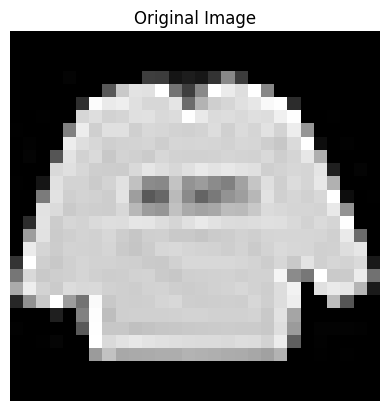

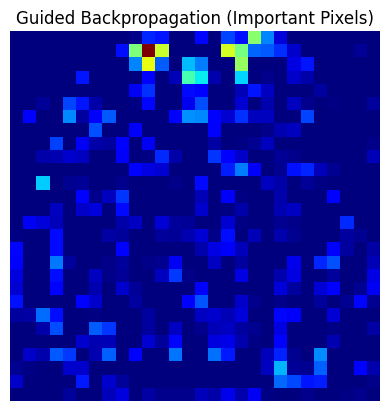

In [25]:
# week-10
# 🔹 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical

# 🔹 Load CSV dataset
data = pd.read_csv('/content/fashion-mnist_train[1].csv')

X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 🔹 Preprocess
X = X.astype('float32') / 255
X = X.reshape(-1, 28, 28, 1)

y = to_categorical(y, 10)

# 🔹 Build model
model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 🔹 Train model
model.fit(X, y, epochs=3, batch_size=128)

# 🔹 Select one image (use Variable for gradients)
img = tf.Variable(X[0:1])

# 🔹 Guided Backpropagation
with tf.GradientTape() as tape:
    preds = model(img)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

# 🔹 Compute gradients
grads = tape.gradient(loss, img)

# 🔹 Guided Backprop (only positive gradients)
guided_grads = tf.maximum(grads, 0)

# 🔹 Convert to numpy
guided_grads = guided_grads.numpy()[0]

# 🔹 Plot original image (FIXED)
plt.imshow(img.numpy()[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# 🔹 Plot guided backpropagation result
plt.imshow(guided_grads.reshape(28,28), cmap='jet')
plt.title("Guided Backpropagation (Important Pixels)")
plt.axis('off')
plt.show()



# 🧪 📊 **OBSERVATIONS: Guided Backpropagation**

---

## 🔹 1. Model Prediction Behavior

* The CNN model successfully predicts the class of the input image.
* The prediction is based on learned features from training data.

### Observation:

* The model focuses on **specific regions** rather than the entire image.

---

## 🔹 2. Gradient-Based Pixel Importance

* Gradients represent how much each pixel affects the prediction.

### Observation:

* Pixels with higher gradient values contribute more to the predicted class.
* Low-gradient pixels have minimal influence.

---

## 🔹 3. Effect of Guided Backpropagation

* Guided Backpropagation keeps only **positive gradients**.

### Observation:

* Negative influences are removed.
* The resulting visualization is **clearer and less noisy** compared to raw gradients.

---

## 🔹 4. Visualization of Important Regions

* The output heatmap highlights important pixels.

### Observation:

* Bright regions (red/yellow) indicate strong influence.
* Dark regions (blue) indicate weak or no influence.

---

## 🔹 5. Feature Learning Insight

* The model mainly focuses on:

  * edges
  * contours
  * object boundaries

### Observation:

* Background pixels are mostly ignored.
* The model relies on **shape features** rather than full image details.

---

## 🔹 6. Spatial Understanding

* Important pixels are concentrated around the object.

### Observation:

* The CNN preserves spatial structure and learns meaningful patterns.

---

## 🔹 7. Model Interpretability

* Guided Backpropagation provides insight into model decisions.

### Observation:

* The CNN is no longer a black box.
* The reasoning behind predictions becomes visible.

---

## 🔹 8. Detection of Model Issues

* Visualization helps identify model problems.

### Observation:

* If highlighted regions are random → poor training.
* If focus is on background → model is incorrect.

---

## 🔹 9. Impact on Performance

* Guided Backpropagation does not change model accuracy.

### Observation:

* It is an analysis tool, not a training method.
* Helps improve performance indirectly by guiding model improvements.

---

## 🔹 10. Overall Understanding

* CNN extracts features through convolution layers.
* Guided Backpropagation traces these features back to input pixels.

---

# 🧾 ✅ **FINAL CONCLUSION**

* Guided Backpropagation highlights the important pixels influencing the model’s prediction.
* It improves interpretability of CNN models.
* It helps in debugging and refining model architecture.
* It does not directly affect performance but aids in improving it indirectly.

---

# 🔥 One-line summary

👉 *“Guided Backpropagation reveals which pixels the CNN used to make its decision.”*

---

